In [ ]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
print(tf.__version__)


C:\Users\eagle\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\eagle\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


2.15.0


In [7]:
from tensorflow import keras

In [ ]:
!pip uninstall keras
#pip install tensorflow


In [3]:
from tensorflow.keras import layers

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [9]:

# 1. Load and prepare the MNIST dataset
# MNIST is a dataset of handwritten digits (0-9).
# It's commonly used as a "Hello, World" for machine learning.
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [11]:
print(y_train[0])

5


In [13]:
# Normalize pixel values to be between 0 and 1.
# Image pixel values range from 0 to 255. Scaling them helps neural networks train better.
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


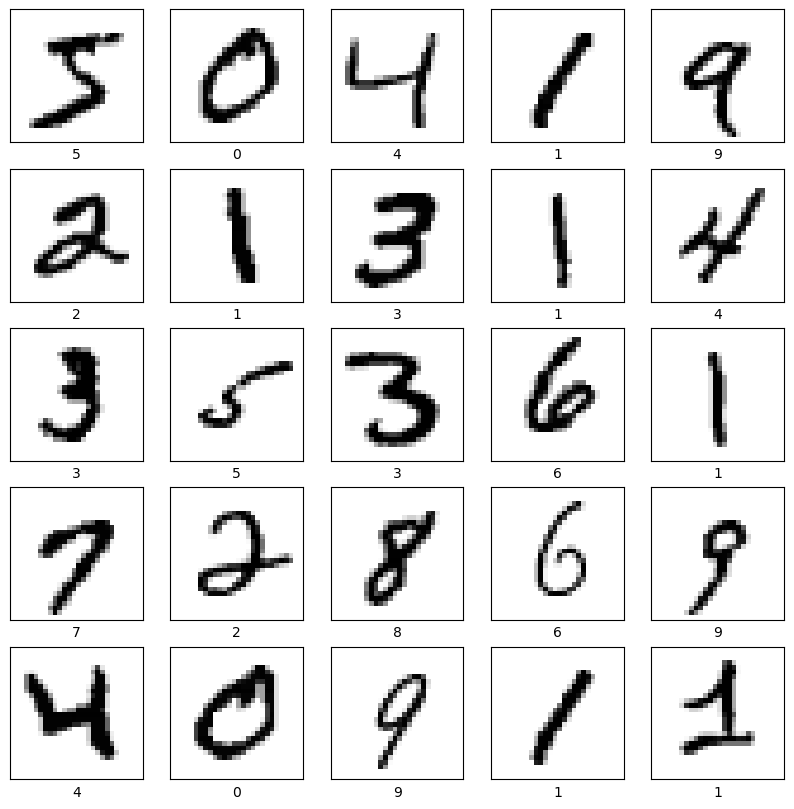

In [15]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i]) # Display the label (digit) below the image
plt.show()

In [17]:
# 2. Build a machine learning model (Neural Network)
# We'll use a Sequential model, which is a linear stack of layers.
model = tf.keras.models.Sequential([
    # Flatten the 28x28 2D image array into a 1D array of 784 pixels.
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # A Dense (fully connected) layer with 128 neurons and ReLU activation.
    # ReLU (Rectified Linear Unit) is a common activation function.
    tf.keras.layers.Dense(128, activation='relu'),

    # Dropout layer to prevent overfitting. It randomly sets a fraction of input units to 0.
    tf.keras.layers.Dropout(0.2),

    # Output Dense layer with 10 neurons (one for each digit 0-9).
    # This layer will output logits (raw predictions).
    tf.keras.layers.Dense(10)
])

In [19]:


# 3. Configure the model for training
# We need to define the optimizer, loss function, and metrics.
# Loss function: SparseCategoricalCrossentropy is suitable for integer labels (like our digits).
# from_logits=True means the output layer returns raw logits, which the loss function will convert to probabilities internally.
# Optimizer: 'adam' is a popular and effective optimizer.
# Metrics: 'accuracy' will be monitored during training and evaluation.
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

In [21]:
# 4. Train the model
# The model.fit method trains the model for a fixed number of epochs.
# An epoch is one complete pass through the entire training dataset.
print("\nTraining the model...")
model.fit(x_train, y_train, epochs=5)


Training the model...
Epoch 1/5


1875/1875 [==============================] - 4s 2ms/step - loss: 0.2973 - accuracy: 0.9132
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1419 - accuracy: 0.9576
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1075 - accuracy: 0.9668
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0856 - accuracy: 0.9738
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0739 - accuracy: 0.9768


In [23]:

# 5. Evaluate the model
# Evaluate the model's performance on the test dataset.
print("\nEvaluating the model...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")


Evaluating the model...
313/313 - 1s - loss: 0.0804 - accuracy: 0.9756 - 510ms/epoch - 2ms/step

Test accuracy: 0.9756


In [25]:
# 6. Make predictions
# If you want the model to output probabilities, wrap it with a Softmax layer.
# Softmax converts logits to probabilities, summing to 1 across all classes.
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

# Predict the probabilities for the first few test images.
predictions = probability_model.predict(x_test[:5])

1/1 [==============================] - 0s 89ms/step


In [29]:

# Print the predicted probabilities and the actual labels for verification.
print("\nPredictions for the first 5 test images:")
for i in range(len(predictions)):
    predicted_class = np.argmax(predictions[i])
    actual_class = y_test[i]
    print(f"Image {i+1}: Predicted: {predicted_class}, Actual: {actual_class},Probabilities: {predictions[i].round(2)}")


Predictions for the first 5 test images:
Image 1: Predicted: 7, Actual: 7,Probabilities: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Image 2: Predicted: 2, Actual: 2,Probabilities: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
Image 3: Predicted: 1, Actual: 1,Probabilities: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 4: Predicted: 0, Actual: 0,Probabilities: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 5: Predicted: 4, Actual: 4,Probabilities: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


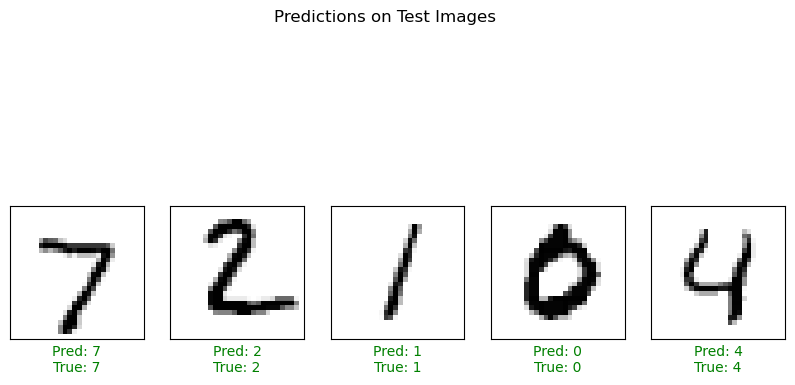


Demo complete!


In [31]:
# You can also visualize the predictions
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]
    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
plt.suptitle("Predictions on Test Images", y=1.02)
plt.show()

print("\nDemo complete!")

In [ ]:
print(y_train,y_test)

[5 0 4 ... 5 6 8] [7 2 1 ... 4 5 6]


In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]


In [25]:
import  tensorflow as tf
from keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras import models
import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import cifar10

In [27]:
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

 58482688/170498071 [=========>....................] - ETA: 8:20

KeyboardInterrupt: 

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [ ]:
Y_train=Y_train.reshape(-1,)

In [ ]:
def plot_sample(x,y,index):
  plt.figure(figsize=(1, 1))
  plt.imshow(x[index])
  plt.xlabel(class_names[y[index]])

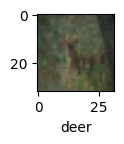

In [ ]:
plot_sample(X_train,Y_train,10)

In [ ]:
X_train=X_train/255
X_test=X_test/255

In [ ]:
Filter_size=3
Num_filters=32
Input_size=32
Maxpool_size=2

In [ ]:
model=Sequential()
model.add(layers.Conv2D(filters=Num_filters,activation="relu",
                        kernel_size=(Filter_size,Filter_size),
                        input_shape=(Input_size,Input_size,3)))

model.add(layers.Conv2D(filters=Num_filters,activation="relu",
                        kernel_size=(Filter_size,Filter_size)))

model.add(layers.MaxPooling2D((Maxpool_size, Maxpool_size)))
model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(filters=Num_filters*2,activation="relu",
                        kernel_size=(Filter_size,Filter_size)))

model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(filters=Num_filters*2,activation="relu",
                        kernel_size=(Filter_size,Filter_size)))
model.add(layers.Dropout(0.2))

model.add(layers.MaxPooling2D((Maxpool_size, Maxpool_size)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128,activation="relu"))
model.add(layers.Dense(10,activation="softmax"))
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(X_train,Y_train,epochs=5)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 191s 120ms/step - accuracy: 0.3227 - loss: 1.8164
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.5445 - loss: 1.2711
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 122ms/step - accuracy: 0.5993 - loss: 1.1238
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 123ms/step - accuracy: 0.6408 - loss: 1.0130
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 208s 126ms/step - accuracy: 0.6683 - loss: 0.9413


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7026 - loss: 0.8635
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]
[3 8 8 0 6]
ship


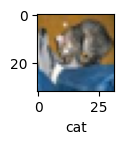

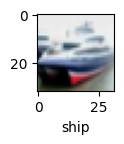

In [ ]:
model.evaluate(X_test,Y_test)

Y_test=Y_test.reshape(-1,)
Y_test[:5]

plot_sample(X_test,Y_test,0)
y_pred=model.predict(X_test)
y_classes=[np.argmax(element) for element in y_pred]
print(y_classes[:5])
print(Y_test[:5])

plot_sample(X_test,Y_test,1)
print(class_names[y_classes[1]])

In [1]:
import tensorflow as tf

In [3]:
import os
data_dir="data//PetImages"

In [5]:
print(os.listdir(data_dir))

['Cat', 'Dog']


In [7]:
classes=os.listdir(data_dir)

In [9]:
import cv2 as cv
X=[]
y=[]
count=0
for label in classes:
    for image in os.listdir(os.path.join(data_dir,label)):
        #print(str(os.path.join(data_dir, label+'/'+image)))
        img=cv.imread(data_dir+"//"+label+"//"+image)
        if img is None:
            print(f"Error: Image not loaded. Check the path: {str(os.path.join(data_dir, label+'/'+image))}")
        else:
            img=cv.resize(img,(32,32))
            img=cv.cvtColor(img,cv.COLOR_BGR2RGB)
            X.append(img)
            y.append(label)

Error: Image not loaded. Check the path: data//PetImages\Cat/140.jpg
Error: Image not loaded. Check the path: data//PetImages\Cat/660.jpg
Error: Image not loaded. Check the path: data//PetImages\Cat/850.jpg
Error: Image not loaded. Check the path: data//PetImages\Cat/936.jpg
Error: Image not loaded. Check the path: data//PetImages\Dog/1308.jpg
Error: Image not loaded. Check the path: data//PetImages\Dog/1866.jpg


In [31]:
# Assuming 'labels' is a list of strings like ['cat''dog''cat']
y = [1 if label == 'Dog' else 0 for label in y]


In [33]:
from sklearn.model_selection import train_test_split
# X and y are your image data array and label array, respectively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
import numpy as np
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [15]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

In [17]:
import  tensorflow as tf
from keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras import models
import matplotlib.pyplot as plt
import numpy as np

In [19]:
Filter_size=3
Num_filters=32
Input_size=32
Maxpool_size=2

In [41]:
model=Sequential()
model.add(layers.Conv2D(filters=Num_filters,activation="relu",
                        kernel_size=(Filter_size,Filter_size),
                        input_shape=(Input_size,Input_size,3)))

model.add(layers.Conv2D(filters=Num_filters,activation="relu",
                        kernel_size=(Filter_size,Filter_size)))

model.add(layers.MaxPooling2D((Maxpool_size, Maxpool_size)))
model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(filters=Num_filters*2,activation="relu",
                        kernel_size=(Filter_size,Filter_size)))

model.add(layers.Dropout(0.2))
model.add(layers.Conv2D(filters=Num_filters*2,activation="relu",
                        kernel_size=(Filter_size,Filter_size)))
model.add(layers.Dropout(0.2))

model.add(layers.MaxPooling2D((Maxpool_size, Maxpool_size)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128,activation="relu"))
model.add(layers.Dense(1,activation="sigmoid"))
model.compile(optimizer="adam",loss="binary_crossentropy",
              metrics=["accuracy"])
model.fit(X_train,y_train,epochs=50)

Epoch 1/50
100/100 [==============================] - 9s 68ms/step - loss: 2.2650 - accuracy: 0.5117
Epoch 2/50
100/100 [==============================] - 7s 66ms/step - loss: 0.6845 - accuracy: 0.5512
Epoch 3/50
100/100 [==============================] - 7s 68ms/step - loss: 0.6852 - accuracy: 0.5606
Epoch 4/50
100/100 [==============================] - 6s 60ms/step - loss: 0.6677 - accuracy: 0.5981
Epoch 5/50
100/100 [==============================] - 6s 61ms/step - loss: 0.6638 - accuracy: 0.6013
Epoch 6/50
100/100 [==============================] - 6s 60ms/step - loss: 0.6463 - accuracy: 0.6200
Epoch 7/50
100/100 [==============================] - 7s 67ms/step - loss: 0.6569 - accuracy: 0.6100
Epoch 8/50
100/100 [==============================] - 7s 69ms/step - loss: 0.6363 - accuracy: 0.6423
Epoch 9/50
100/100 [==============================] - 6s 57ms/step - loss: 0.6423 - accuracy: 0.6213
Epoch 10/50
100/100 [==============================] - 6s 60ms/step - loss: 0.6274 - accura

In [45]:
from keras.preprocessing.image import ImageDataGenerator

In [47]:
image_gen=ImageDataGenerator(rotation_range=30,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode='nearest')

In [49]:
image_gen_=ImageDataGenerator(rescale=1./255)

In [51]:
gen_set=image_gen_.\
        flow_from_directory(data_dir,
                            target_size=(32,32),
                            batch_size=10,
                            class_mode='binary')

Found 4000 images belonging to 2 classes.


In [53]:
model.fit_generator(gen_set,steps_per_epoch=10,epochs=10,verbose=1)

C:\Users\eagle\AppData\Local\Temp\ipykernel_13696\1103053497.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(gen_set,steps_per_epoch=10,epochs=10,verbose=1)


Epoch 1/10
10/10 [==============================] - 2s 77ms/step - loss: 0.8992 - accuracy: 0.5100
Epoch 2/10
10/10 [==============================] - 1s 66ms/step - loss: 0.7173 - accuracy: 0.4600
Epoch 3/10
10/10 [==============================] - 1s 70ms/step - loss: 0.6927 - accuracy: 0.5400
Epoch 4/10
10/10 [==============================] - 1s 72ms/step - loss: 0.6985 - accuracy: 0.4600
Epoch 5/10
10/10 [==============================] - 1s 74ms/step - loss: 0.6949 - accuracy: 0.4700
Epoch 6/10
10/10 [==============================] - 1s 70ms/step - loss: 0.6933 - accuracy: 0.5500
Epoch 7/10
10/10 [==============================] - 1s 82ms/step - loss: 0.6968 - accuracy: 0.5000
Epoch 8/10
10/10 [==============================] - 1s 70ms/step - loss: 0.6990 - accuracy: 0.4200
Epoch 9/10
10/10 [==============================] - 1s 66ms/step - loss: 0.6925 - accuracy: 0.5100
Epoch 10/10
10/10 [==============================] - 1s 72ms/step - loss: 0.6889 - accuracy: 0.5300
